In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
dfclientes = pd.read_parquet(r'C:\Users\pablo\iCloudDrive\Master - ThePower\Data Analyst V3\Repositoros_GitHub\Entrega_Phyton_For_Data\Entrega-Proyecto-Python-EDA\DataProyecto/Limpio/clientes_clean.parquet')
dfbank = pd.read_parquet(r'C:\Users\pablo\iCloudDrive\Master - ThePower\Data Analyst V3\Repositoros_GitHub\Entrega_Phyton_For_Data\Entrega-Proyecto-Python-EDA\DataProyecto/Limpio/bank_clean.parquet')

df_merge = pd.merge(dfbank, dfclientes, on="ID", how="left")
df_merge

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,y,date,latitude,longitude,ID,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth
0,<NA>,housemaid,MARRIED,basic.4y,False,False,False,telephone,261,1,...,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04,29
1,57,services,MARRIED,high.school,True,False,False,telephone,149,1,...,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30,7
2,37,services,MARRIED,high.school,False,True,False,telephone,226,1,...,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,2012-02-02,5
3,40,admin.,MARRIED,basic.6y,False,False,False,telephone,151,1,...,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,2012-12-21,29
4,56,services,MARRIED,high.school,False,False,True,telephone,307,1,...,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,2012-06-20,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,<NA>,admin.,MARRIED,university.degree,False,False,False,cellular,618,2,...,yes,2015-10-13,38.147,-105.582,4eed05de-2a98-4227-b488-32122009b638,68672,0,2,2014-03-08,22
42996,34,technician,MARRIED,professional.course,False,True,True,cellular,42,7,...,no,2018-03-17,49.235,-112.201,0f0aca88-4088-4fe2-905f-44fb675d9493,73578,0,2,2014-03-11,26
42997,<NA>,blue-collar,SINGLE,basic.6y,False,True,False,cellular,391,2,...,no,2016-09-15,40.679,-120.015,cadadd4b-7ee5-4019-b13a-ca01bb67ca5b,9816,2,2,2014-09-18,31
42998,<NA>,admin.,MARRIED,university.degree,True,False,False,cellular,674,3,...,no,2019-09-23,27.772,-117.518,5f432048-d515-4bb5-9c94-62db451f88d4,156980,1,2,2014-05-17,7


In [84]:
print("Bank:", dfbank.shape[0])
print("Clientes:", dfclientes.shape[0])

Bank: 43000
Clientes: 43170


In [85]:
df_merge.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'date', 'latitude', 'longitude', 'ID', 'Income',
       'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth'],
      dtype='object')

Normalizamos nombres de las columnas

In [86]:
df_merge.columns = (
    df_merge.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('[^a-z0-9_]', '', regex=True)
)

In [87]:
df_merge.head(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,y,date,latitude,longitude,id,income,kidhome,teenhome,dt_customer,numwebvisitsmonth
0,<NA>,housemaid,MARRIED,basic.4y,False,False,False,telephone,261,1,...,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04,29
1,57,services,MARRIED,high.school,True,False,False,telephone,149,1,...,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30,7
2,37,services,MARRIED,high.school,False,True,False,telephone,226,1,...,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,2012-02-02,5
3,40,admin.,MARRIED,basic.6y,False,False,False,telephone,151,1,...,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,2012-12-21,29
4,56,services,MARRIED,high.school,False,False,True,telephone,307,1,...,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,2012-06-20,20


In [88]:
print("Merge:", df_merge.shape[0]) #mantiene las filas de bank

Merge: 43000


In [89]:
df_merge_check = pd.merge(dfbank, dfclientes, on="ID", how="left", indicator=True)

Para comprobar cuantos ID hay en cada tabla comunes.

In [90]:
print(df_merge_check['_merge'].value_counts())

_merge
both          43000
left_only         0
right_only        0
Name: count, dtype: int64


In [91]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   age                37880 non-null  Int64         
 1   job                42655 non-null  category      
 2   marital            42915 non-null  category      
 3   education          41193 non-null  category      
 4   default            43000 non-null  bool          
 5   housing            43000 non-null  bool          
 6   loan               43000 non-null  bool          
 7   contact            43000 non-null  category      
 8   duration           43000 non-null  int64         
 9   campaign           43000 non-null  int64         
 10  pdays              43000 non-null  int64         
 11  previous           43000 non-null  int64         
 12  poutcome           43000 non-null  category      
 13  empvarrate         43000 non-null  float64       
 14  conspr

In [92]:
df_merge.describe().T

,count,mean,min,25%,50%,75%,max,std
age,37880.0,39.977112,17.0,32.0,38.0,47.0,98.0,10.437957
duration,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
campaign,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
pdays,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
previous,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
empvarrate,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898
conspriceidx,42529.0,93.574219,92.201,93.075,93.749,93.994,94.767,0.579548
consconfidx,43000.0,-40.509049,-50.8,-42.7,-41.8,-36.4,-26.9,4.637186
euribor3m,33744.0,3.616521,0.634,1.344,4.857,4.961,5.045,1.737117
nremployed,43000.0,5166.852602,4963.6,5099.1,5191.0,5228.1,5228.1,72.411125


Revisar duplicados completos

In [93]:
print("Duplicados totales:", df_merge.duplicated().sum())

# Revisar duplicados por clave ID
print("IDs duplicados:", df_merge['id'].duplicated().sum())

# Eliminar duplicados totales si hay
df_merge = df_merge.drop_duplicates()

Duplicados totales: 0
IDs duplicados: 0


Conteo de nulos por columna

In [94]:
df_merge.isnull().sum()

age                  5120
job                   345
marital                85
education            1807
default                 0
housing                 0
loan                    0
contact                 0
duration                0
campaign                0
pdays                   0
previous                0
poutcome                0
empvarrate              0
conspriceidx          471
consconfidx             0
euribor3m            9256
nremployed              0
y                       0
date                  248
latitude                0
longitude               0
id                      0
income                  0
kidhome                 0
teenhome                0
dt_customer             0
numwebvisitsmonth       0
dtype: int64

In [95]:
df_merge.head(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,y,date,latitude,longitude,id,income,kidhome,teenhome,dt_customer,numwebvisitsmonth
0,<NA>,housemaid,MARRIED,basic.4y,False,False,False,telephone,261,1,...,no,2019-08-02,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079,161770,1,0,2012-04-04,29
1,57,services,MARRIED,high.school,True,False,False,telephone,149,1,...,no,2016-09-14,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097,85477,1,1,2012-12-30,7
2,37,services,MARRIED,high.school,False,True,False,telephone,226,1,...,no,2019-02-15,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b,147233,1,1,2012-02-02,5
3,40,admin.,MARRIED,basic.6y,False,False,False,telephone,151,1,...,no,2015-11-29,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e,121393,1,2,2012-12-21,29
4,56,services,MARRIED,high.school,False,False,True,telephone,307,1,...,no,2017-01-29,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,63164,1,2,2012-06-20,20


Comenzamos el análisis con las distribuciones de cada variable

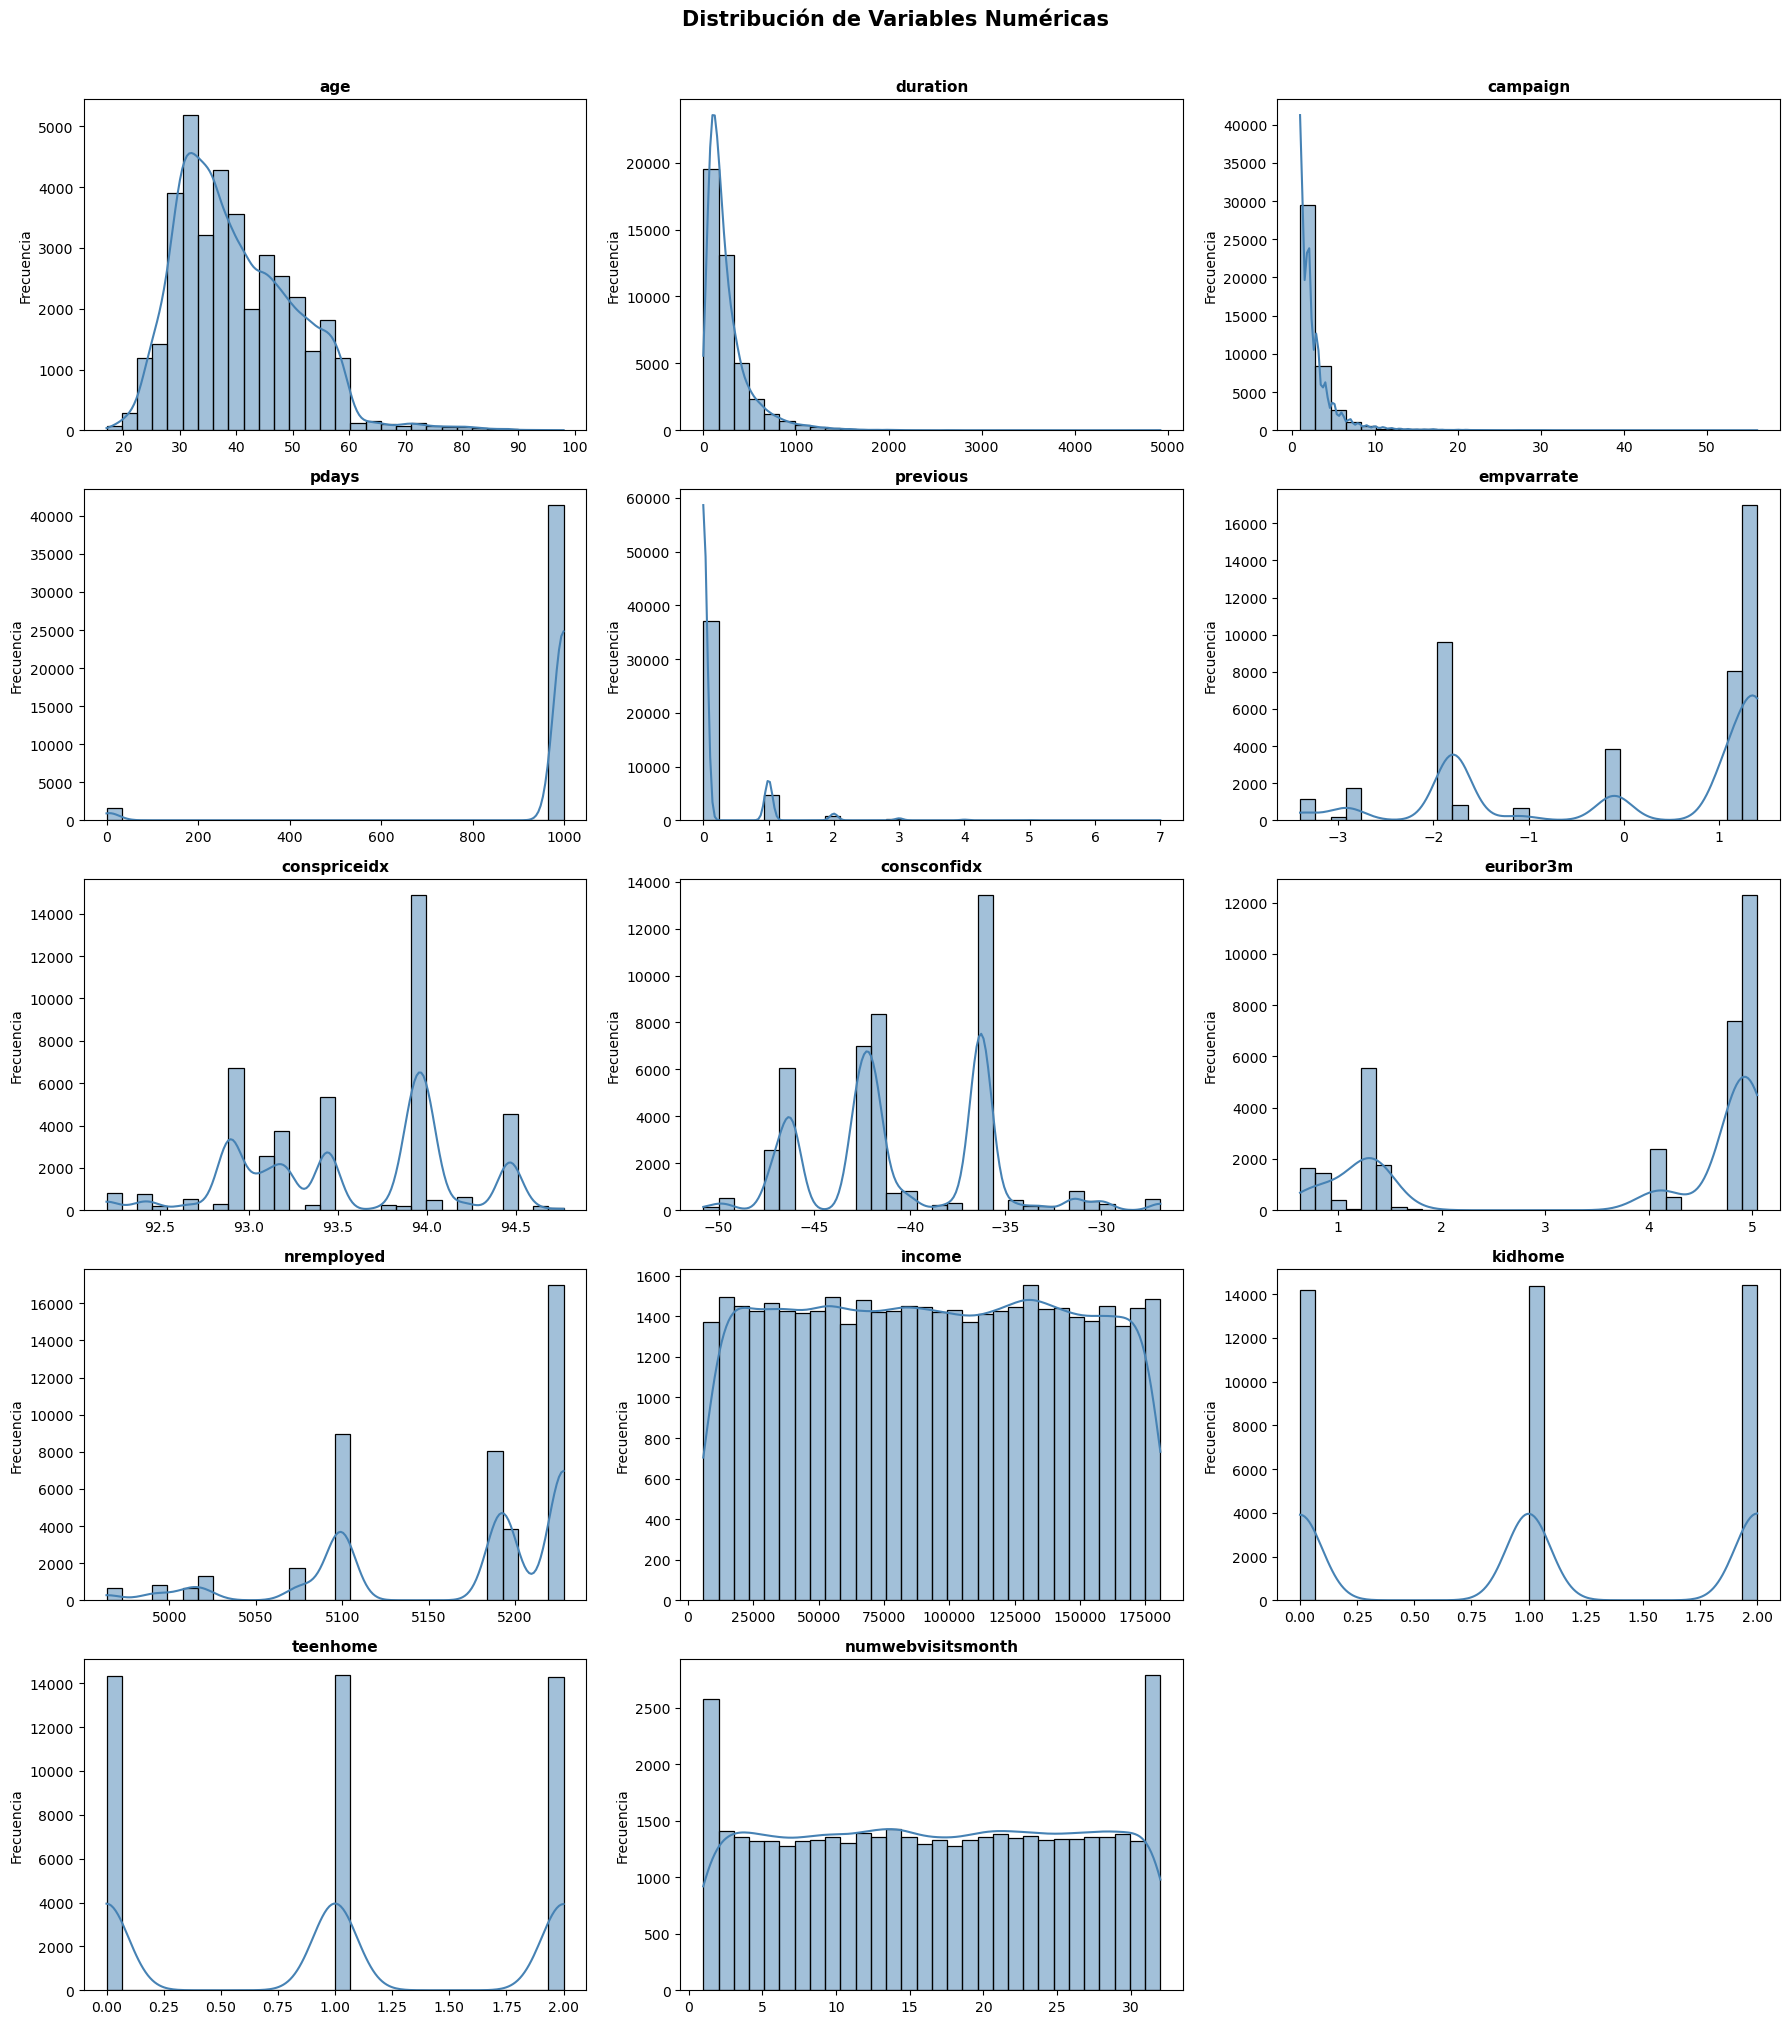

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

numericas = ['age', 'duration', 'campaign', 'pdays', 'previous',
             'empvarrate', 'conspriceidx', 'consconfidx', 'euribor3m',
             'nremployed', 'income', 'kidhome', 'teenhome', 'numwebvisitsmonth']

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(numericas):
    ax = axes[i]
    data = df_merge[col].dropna()
    sns.histplot(data, ax=ax, kde=True, color='steelblue', bins=30)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')

# Ocultar ejes sobrantes
for j in range(len(numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Heatmap de correlación

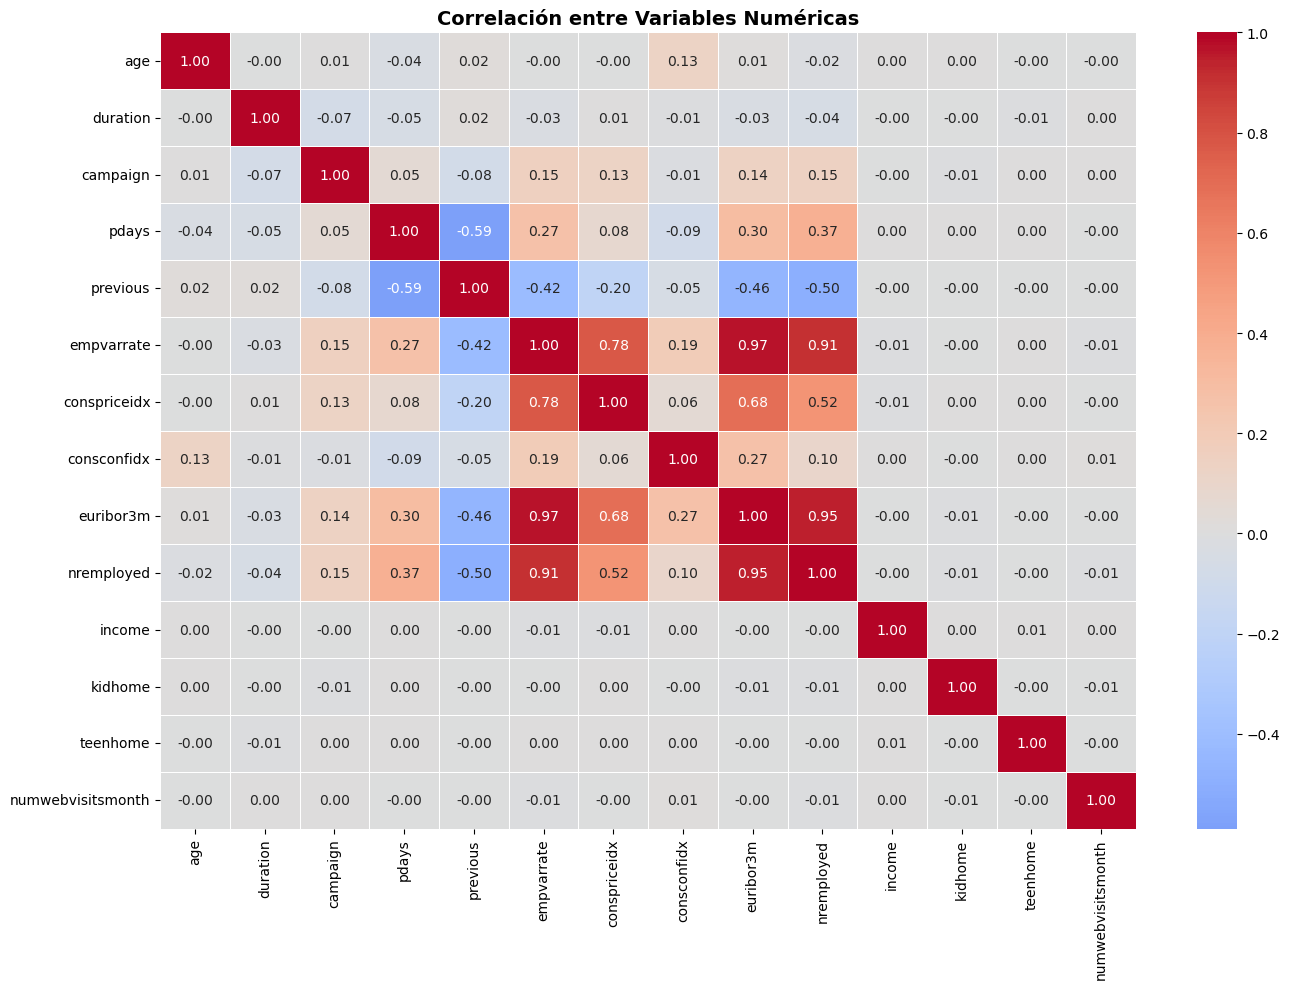

In [97]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df_merge[numericas].corr()
mask = corr.isnull().all()
corr_clean = corr.loc[~mask, ~mask]
sns.heatmap(corr_clean, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlación entre Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Obviamente, podemos ver las mismas características que podíamos ver en el ejemplo de los data sets por separado.

- empvarrate, conspriceidx, consconfidx, euribor3m, nremployed muestran distribuciones multimodales — reflejan distintos momentos macroeconómicos de la campaña. Adenás, hay una alta correlación
- Prácticamente uniformes — probablemente simuladas
- kidhome y teenhome tambien simuladas

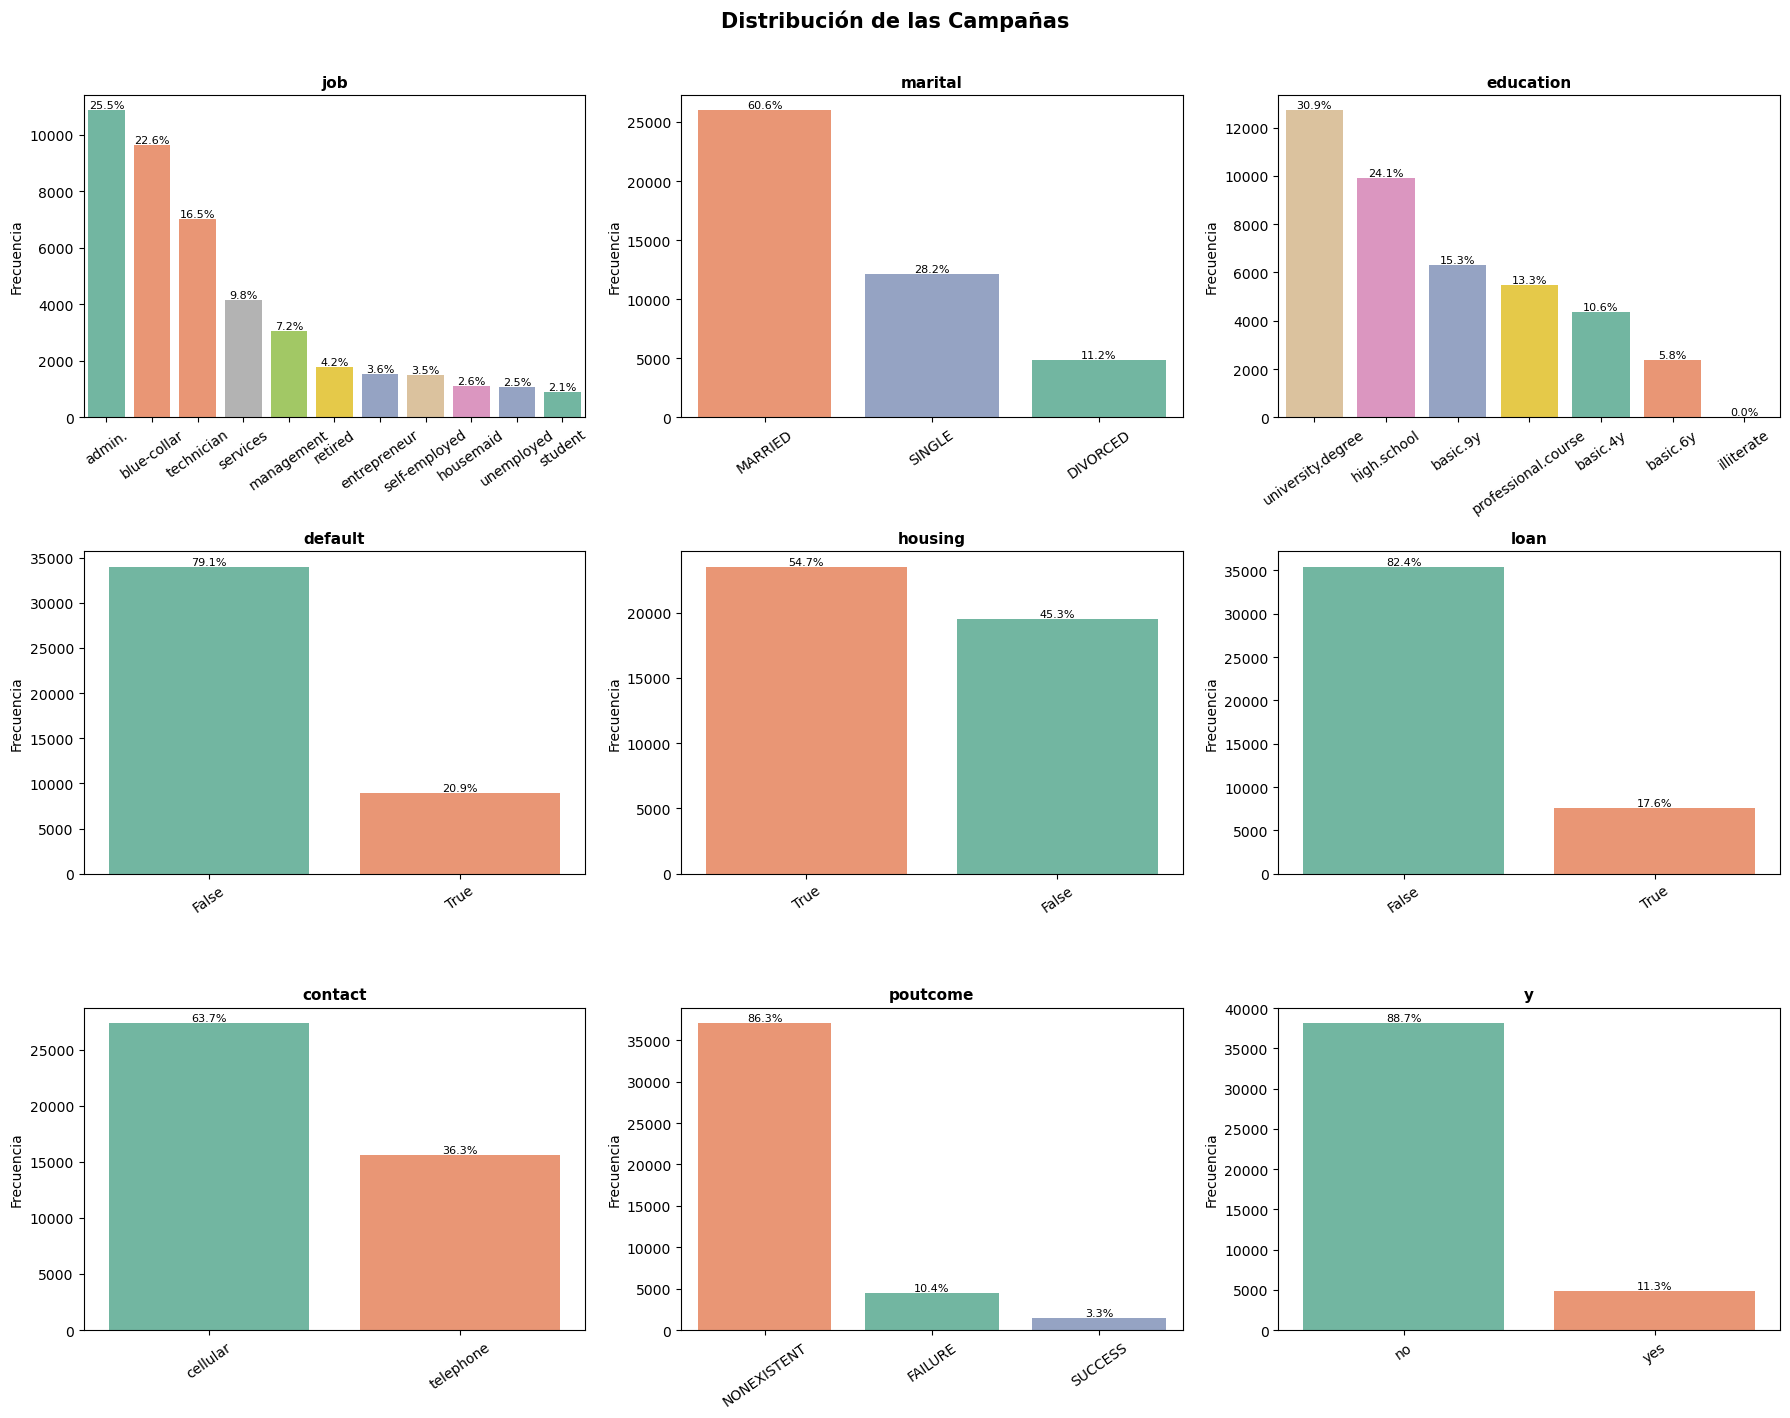

In [98]:
categoricas = ['job', 'marital', 'education', 'default', 'housing',
               'loan', 'contact', 'poutcome', 'y']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    ax = axes[i]
    orden = df_merge[col].value_counts().index
    sns.countplot(data=df_merge, x=col, order=orden, ax=ax,
                  hue=col, palette='Set2', legend=False)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=35)

    # Añadir porcentaje encima de cada barra
    total = df_merge[col].count()
    for p in ax.patches:
        pct = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de las Campañas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

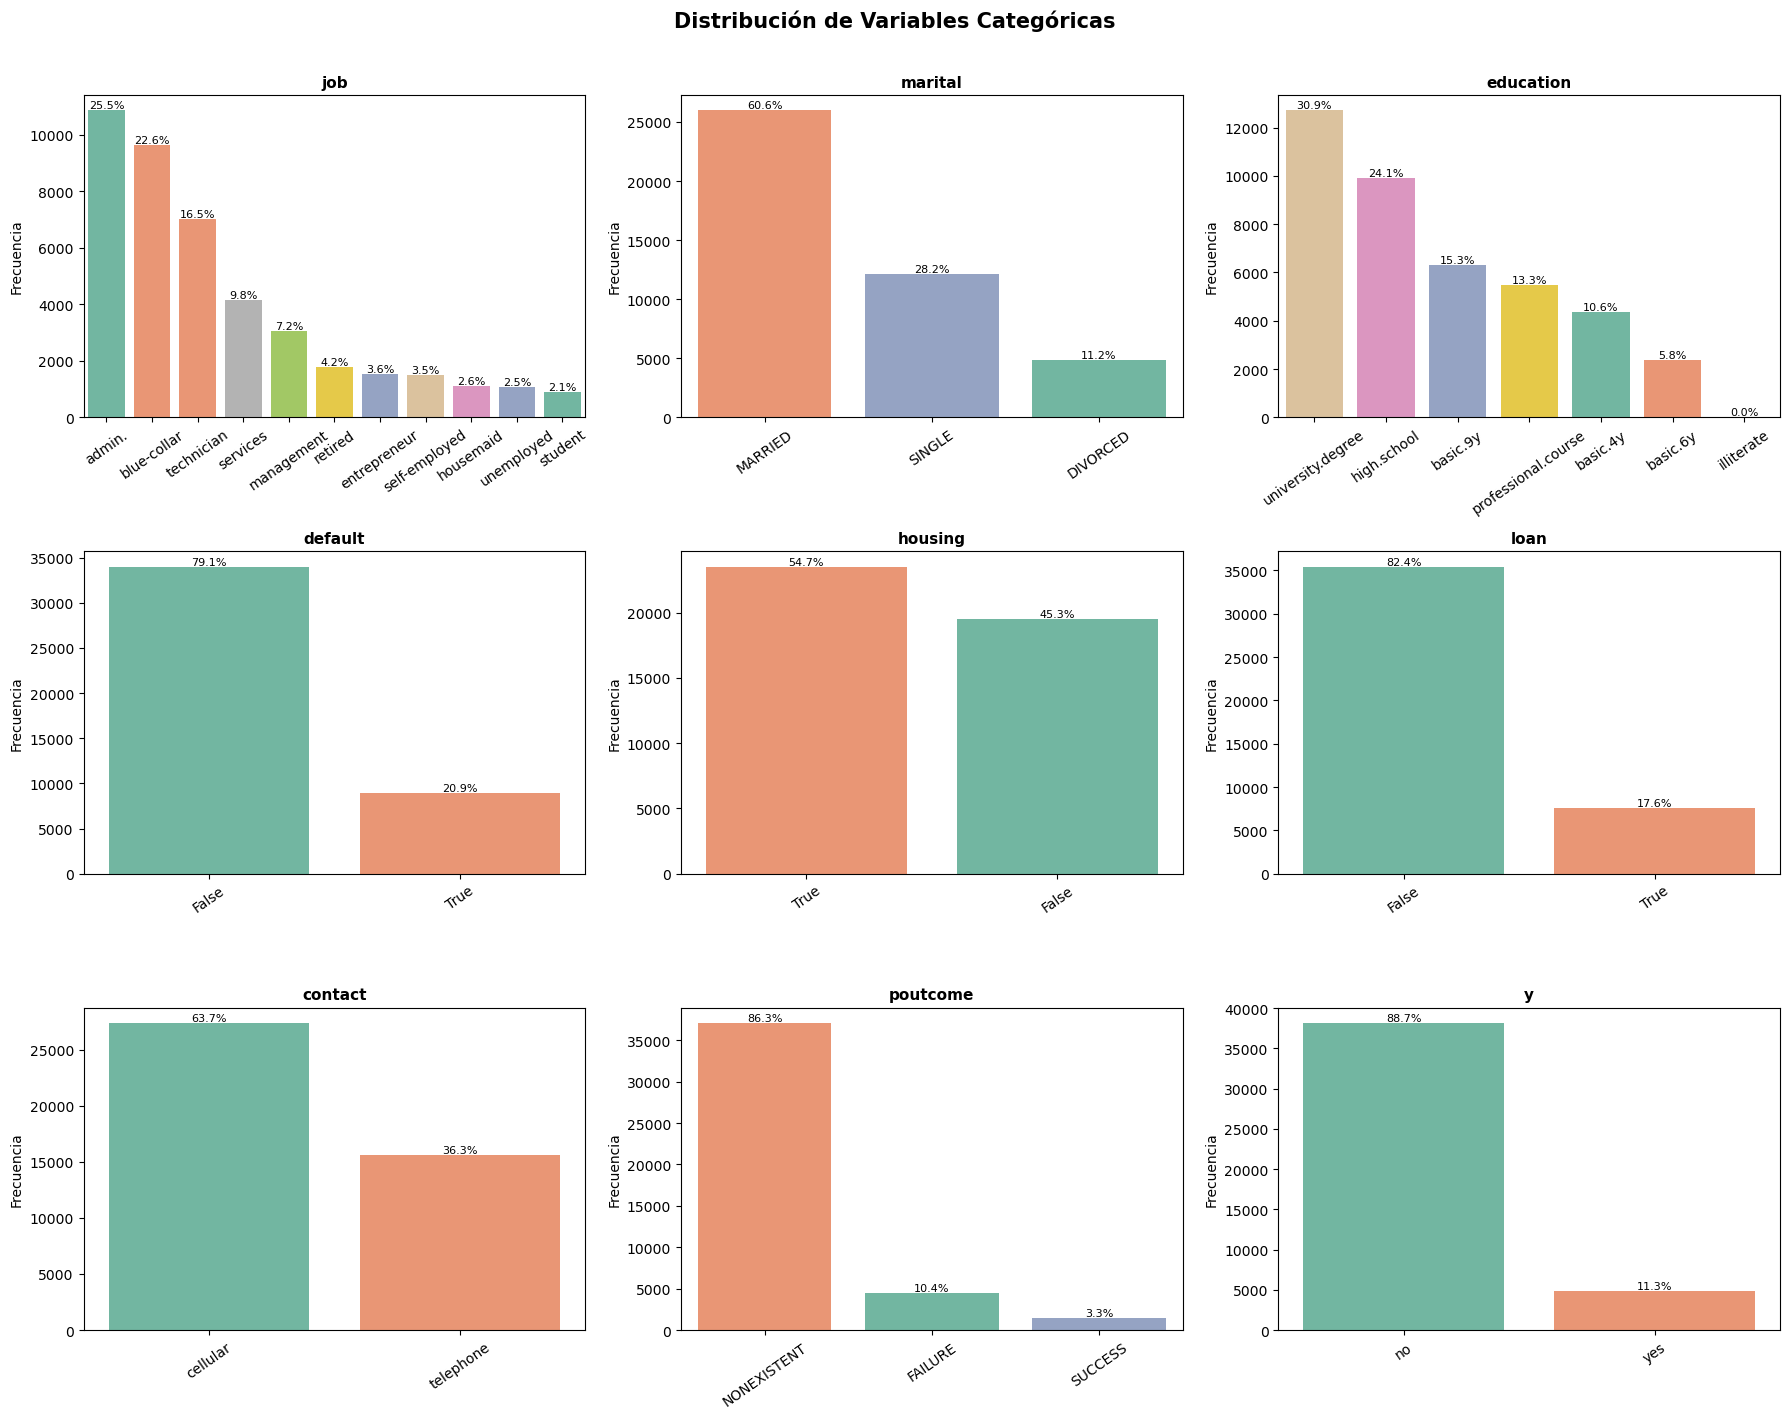

In [99]:
categoricas = ['job', 'marital', 'education', 'default', 'housing',
               'loan', 'contact', 'poutcome', 'y']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    ax = axes[i]
    orden = df_merge[col].value_counts().index
    sns.countplot(data=df_merge, x=col, order=orden, ax=ax,
                  hue=col, palette='Set2', legend=False)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=35)

    total = df_merge[col].count()
    for p in ax.patches:
        pct = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribución de Variables Categóricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Conversión por variables numéricas (boxplot)

C:\Users\pablo\AppData\Local\Temp\ipykernel_30952\1566016712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='y', y=col, ax=ax, palette={'no': 'steelblue', 'yes': 'tomato'},
C:\Users\pablo\AppData\Local\Temp\ipykernel_30952\1566016712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='y', y=col, ax=ax, palette={'no': 'steelblue', 'yes': 'tomato'},
C:\Users\pablo\AppData\Local\Temp\ipykernel_30952\1566016712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='y', y=col, ax=ax, palette=

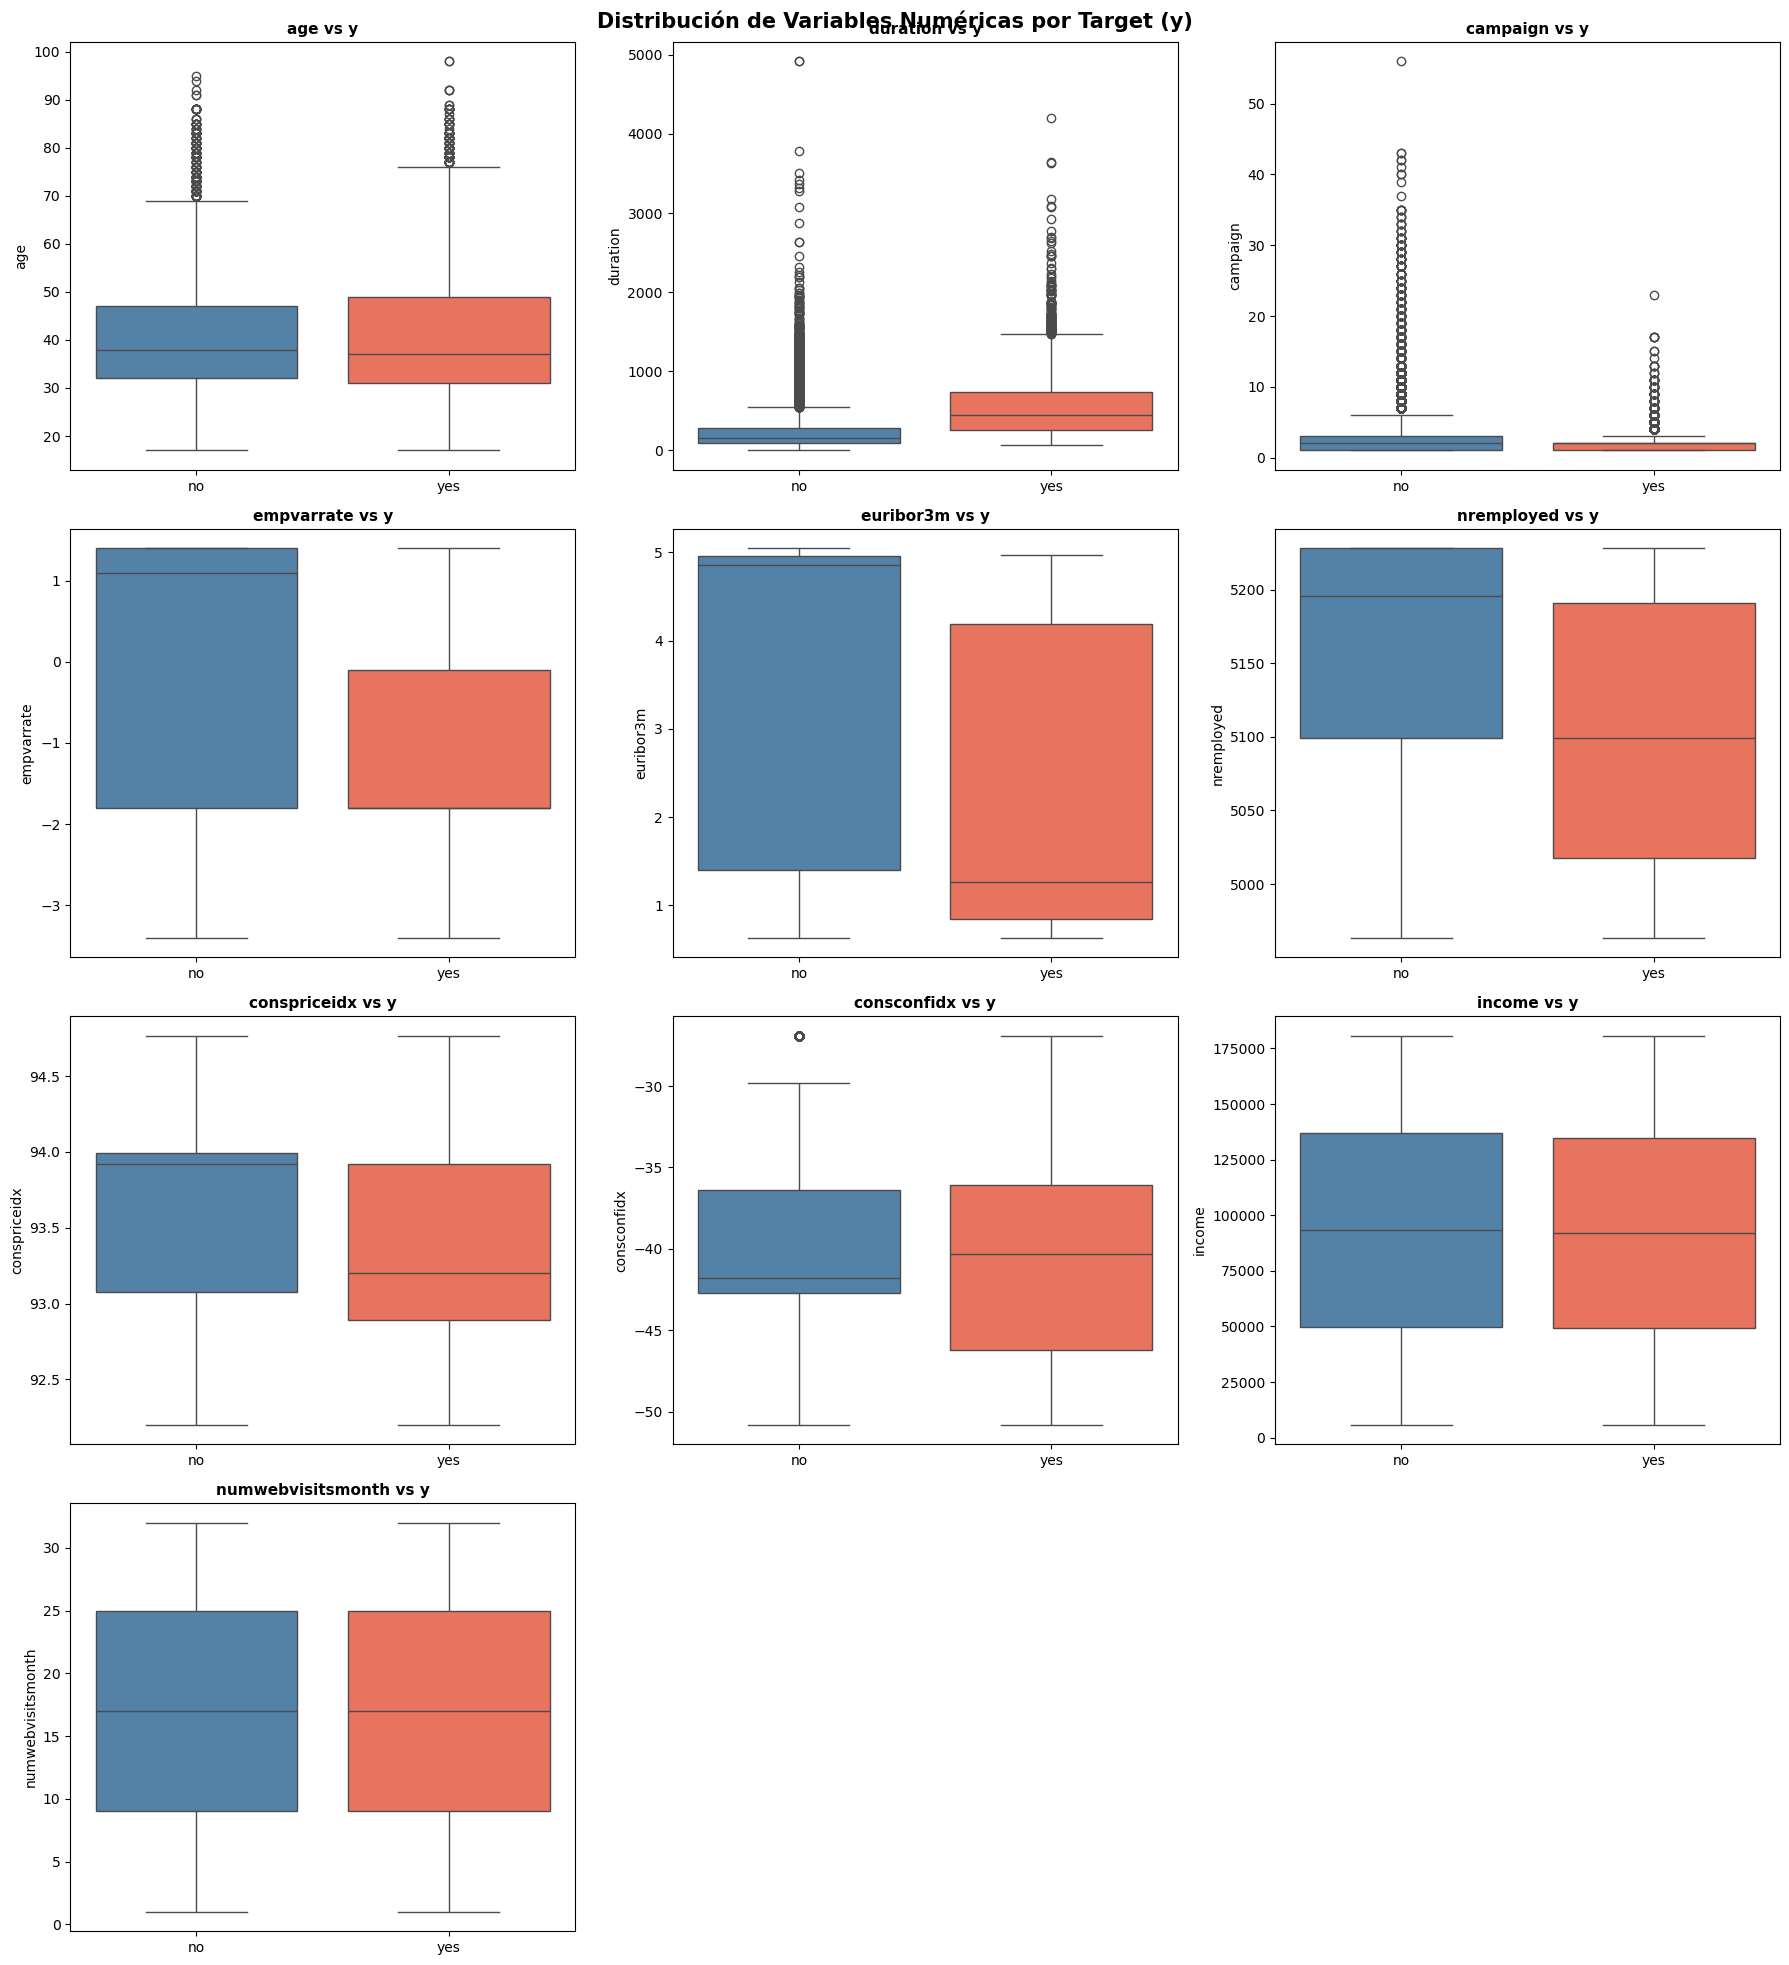

In [100]:
num_vars = ['age', 'duration', 'campaign', 'empvarrate', 'euribor3m', 'nremployed',
            'conspriceidx', 'consconfidx', 'income', 'numwebvisitsmonth']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    ax = axes[i]
    sns.boxplot(data=df_merge, x='y', y=col, ax=ax, palette={'no': 'steelblue', 'yes': 'tomato'},
                order=['no', 'yes'])
    ax.set_title(f'{col} vs y', fontsize=11, fontweight='bold')
    ax.set_xlabel('')

for j in range(len(num_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas por Target (y)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Lo mismo que en análisis anteriores.
- Los que contratan algún producto tienen una duración de llamada más alta.
- Tasas de empleo más bajas correlacionan con más conversiones.
- Euribor bajo → más conversiones (clientes más receptivos en contexto de tipos bajos)

Análisis temporal

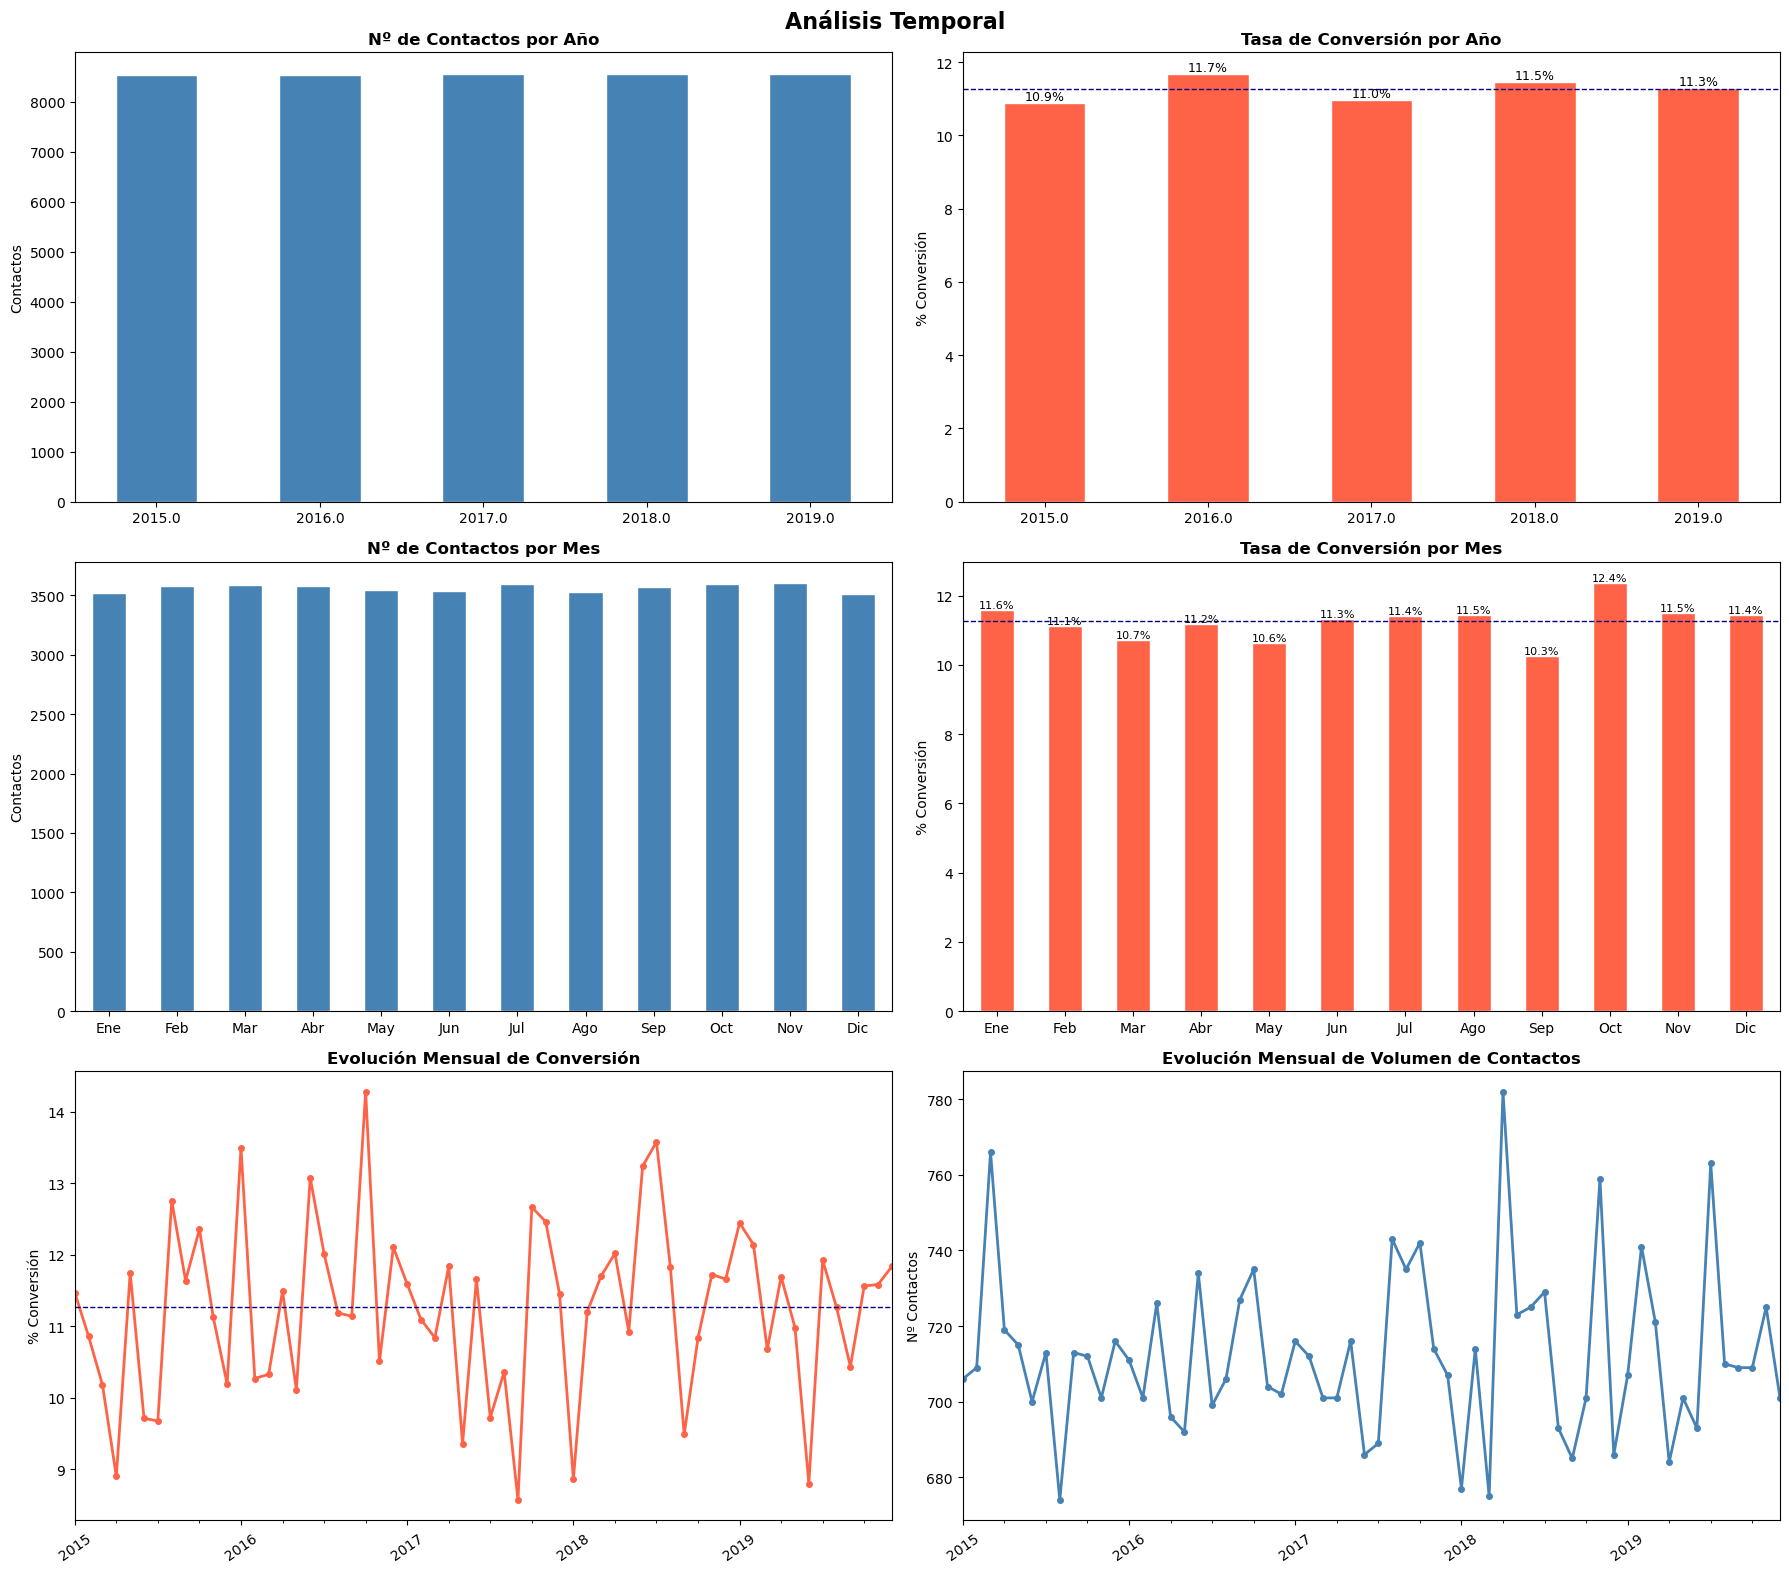

In [102]:
df_merge['y_bin'] = (df_merge['y'] == 'yes').astype(int)

# Extraer año y mes
df_merge['year'] = df_merge['date'].dt.year
df_merge['month'] = df_merge['date'].dt.month
df_merge['year_month'] = df_merge['date'].dt.to_period('M')

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 16))

# --- 1. Nº contactos por año ---
ax = axes[0, 0]
df_merge['year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Nº de Contactos por Año', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Contactos')
ax.tick_params(axis='x', rotation=0)

# --- 2. Tasa de conversión por año ---
ax = axes[0, 1]
conv_year = df_merge.groupby('year')['y_bin'].mean() * 100
conv_year.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.axhline(df_merge['y_bin'].mean() * 100, color='navy', linestyle='--', linewidth=1)
ax.set_title('Tasa de Conversión por Año', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Conversión')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

# --- 3. Nº contactos por mes ---
ax = axes[1, 0]
df_merge['month'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Nº de Contactos por Mes', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Contactos')
ax.set_xticks(range(12))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)

# --- 4. Tasa de conversión por mes ---
ax = axes[1, 1]
conv_month = df_merge.groupby('month')['y_bin'].mean() * 100
conv_month.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.axhline(df_merge['y_bin'].mean() * 100, color='navy', linestyle='--', linewidth=1)
ax.set_title('Tasa de Conversión por Mes', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Conversión')
ax.set_xticks(range(12))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

# --- 5. Serie temporal mensual: conversión ---
ax = axes[2, 0]
conv_ts = df_merge.groupby('year_month')['y_bin'].mean() * 100
conv_ts.plot(ax=ax, color='tomato', linewidth=2, marker='o', markersize=4)
ax.axhline(df_merge['y_bin'].mean() * 100, color='navy', linestyle='--', linewidth=1)
ax.set_title('Evolución Mensual de Conversión', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Conversión')
ax.tick_params(axis='x', rotation=35)

# --- 6. Serie temporal mensual: volumen ---
ax = axes[2, 1]
vol_ts = df_merge.groupby('year_month')['y_bin'].count()
vol_ts.plot(ax=ax, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.set_title('Evolución Mensual de Volumen de Contactos', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nº Contactos')
ax.tick_params(axis='x', rotation=35)

plt.suptitle('Análisis Temporal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\pablo\AppData\Local\Temp\ipykernel_30952\2277667695.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pdays_real, x='y', y='pdays', ax=ax,


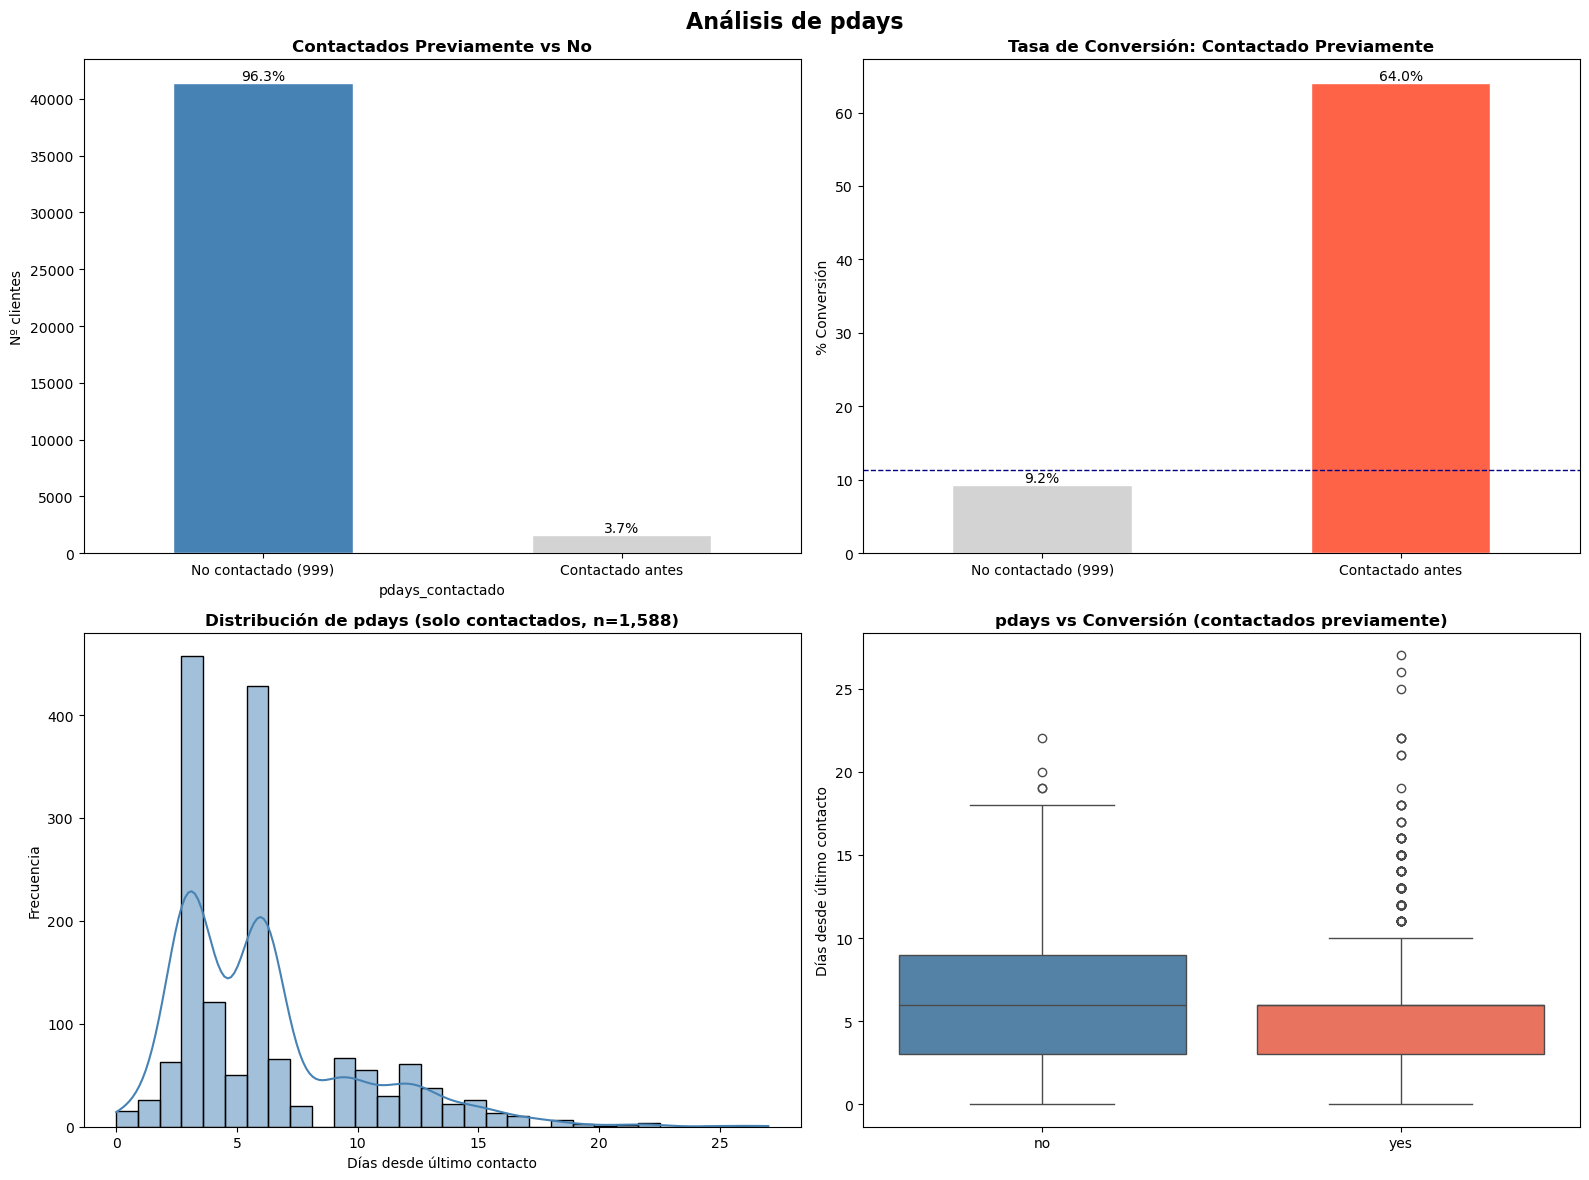


Clientes NO contactados previamente (pdays=999): 41,412 (96.3%)
Clientes contactados previamente: 1,588 (3.7%)

Conversión no contactados: 9.2%
Conversión contactados previamente: 64.0%

pdays reales (sin 999):
count    1588.0
mean        6.1
std         3.9
min         0.0
25%         3.0
50%         6.0
75%         7.0
max        27.0
Name: pdays, dtype: float64


In [103]:
df_merge['y_bin'] = (df_merge['y'] == 'yes').astype(int)

# Separar: 999 = no contactado previamente
df_merge['pdays_contactado'] = df_merge['pdays'] != 999
df_pdays_real = df_merge[df_merge['pdays'] != 999].copy()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

#1. Proporción contactados vs no contactados
ax = axes[0, 0]
counts = df_merge['pdays_contactado'].map({True: 'Contactado antes', False: 'No contactado (999)'}).value_counts()
counts.plot(kind='bar', ax=ax, color=['steelblue', 'lightgray'], edgecolor='white')
ax.set_title('Contactados Previamente vs No', fontweight='bold')
ax.set_ylabel('Nº clientes')
ax.tick_params(axis='x', rotation=0)
total = counts.sum()
for p in ax.patches:
    ax.annotate(f'{100*p.get_height()/total:.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

#2. Tasa de conversión: contactados vs no contactados
ax = axes[0, 1]
conv = df_merge.groupby('pdays_contactado')['y_bin'].mean() * 100
conv.index = ['No contactado (999)', 'Contactado antes']
conv.plot(kind='bar', ax=ax, color=['lightgray', 'tomato'], edgecolor='white')
ax.axhline(df_merge['y_bin'].mean() * 100, color='navy', linestyle='--', linewidth=1)
ax.set_title('Tasa de Conversión: Contactado Previamente', fontweight='bold')
ax.set_ylabel('% Conversión')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

#3. Distribución de pdays reales (sin 999)
ax = axes[1, 0]
sns.histplot(df_pdays_real['pdays'], bins=30, ax=ax, color='steelblue', kde=True)
ax.set_title(f'Distribución de pdays (solo contactados, n={len(df_pdays_real):,})', fontweight='bold')
ax.set_xlabel('Días desde último contacto')
ax.set_ylabel('Frecuencia')

#4. pdays reales vs conversión (boxplot)
ax = axes[1, 1]
sns.boxplot(data=df_pdays_real, x='y', y='pdays', ax=ax,
            palette={'no': 'steelblue', 'yes': 'tomato'}, order=['no', 'yes'])
ax.set_title('pdays vs Conversión (contactados previamente)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Días desde último contacto')

plt.suptitle('Análisis de pdays', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen numérico
print(f"\nClientes NO contactados previamente (pdays=999): {(df_merge['pdays']==999).sum():,} ({100*(df_merge['pdays']==999).mean():.1f}%)")
print(f"Clientes contactados previamente: {(df_merge['pdays']!=999).sum():,} ({100*(df_merge['pdays']!=999).mean():.1f}%)")
print(f"\nConversión no contactados: {df_merge[df_merge['pdays']==999]['y_bin'].mean()*100:.1f}%")
print(f"Conversión contactados previamente: {df_merge[df_merge['pdays']!=999]['y_bin'].mean()*100:.1f}%")
print(f"\npdays reales (sin 999):\n{df_pdays_real['pdays'].describe().round(1)}")

- El 64% de los que se han puesto en contacto previamente han convertido.
- Según la gráfica, es más probable que convierta si pasan pocos días desde el último contacto. La mayoría de re-contactos ocurren en los primeros 5-7 días tras el contacto anterior

C:\Users\pablo\AppData\Local\Temp\ipykernel_30952\1500797934.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='y', y='income', ax=ax,
C:\Users\pablo\AppData\Local\Temp\ipykernel_30952\1500797934.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='y', y='numwebvisitsmonth', ax=ax,
C:\Users\pablo\AppData\Local\Temp\ipykernel_30952\1500797934.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='y', y='antiguedad_dias', ax=ax,


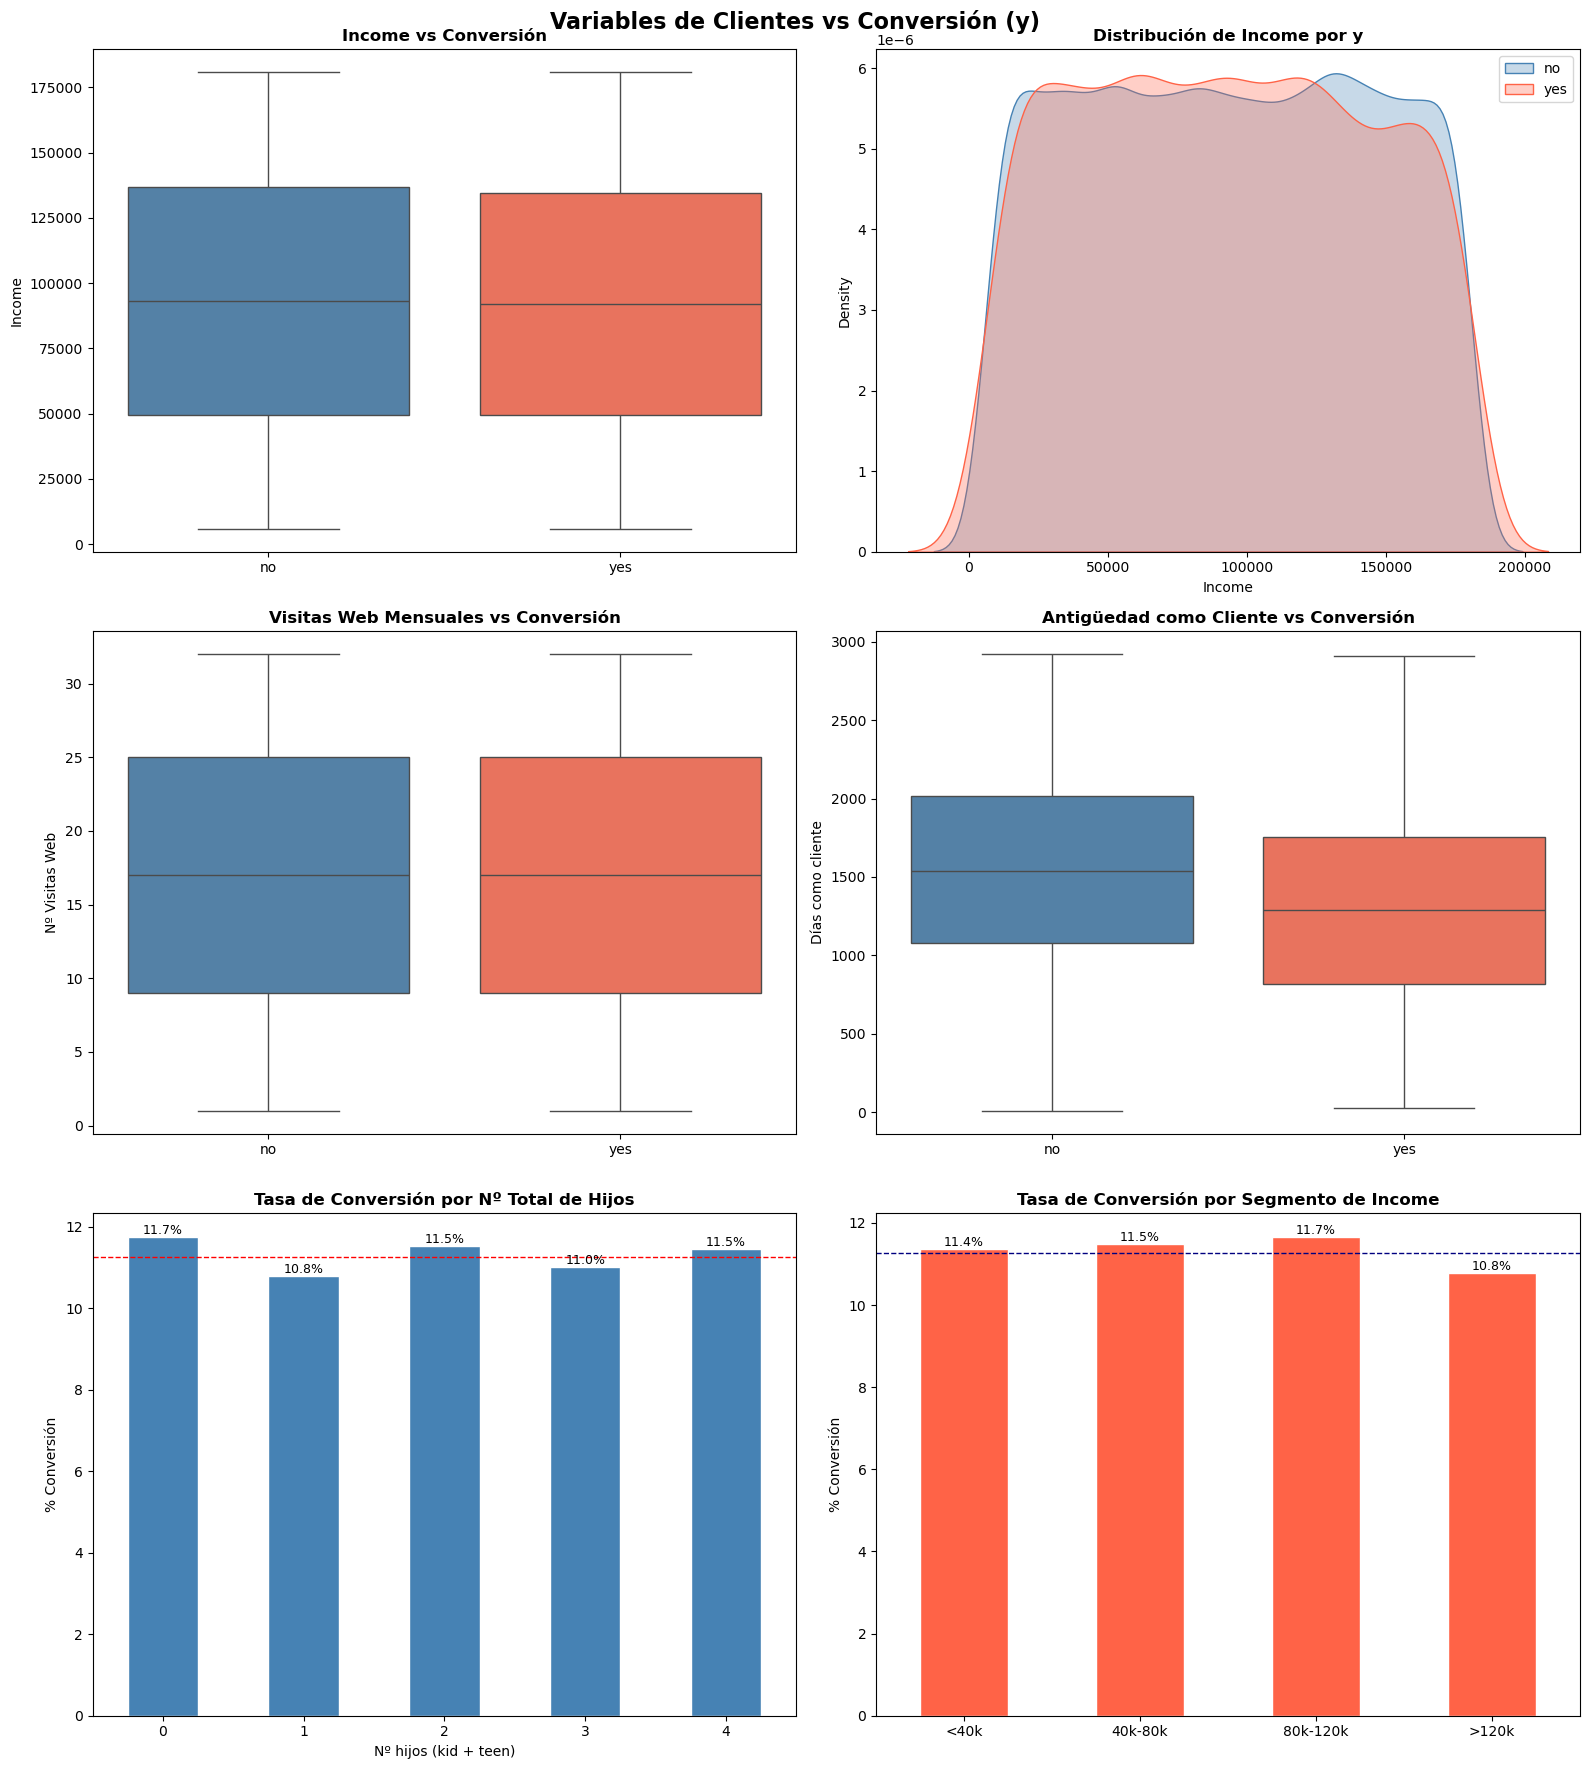

In [113]:
df_merge['y_bin'] = (df_merge['y'] == 'yes').astype(int)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))

# --- 1. Income vs y (boxplot) ---
ax = axes[0, 0]
sns.boxplot(data=df_merge, x='y', y='income', ax=ax,
            palette={'no': 'steelblue', 'yes': 'tomato'}, order=['no', 'yes'])
ax.set_title('Income vs Conversión', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Income')

# --- 2. Income: distribución por y (kde) ---
ax = axes[0, 1]
for val, color in zip(['no', 'yes'], ['steelblue', 'tomato']):
    sns.kdeplot(df_merge[df_merge['y'] == val]['income'], ax=ax, label=val, color=color, fill=True, alpha=0.3)
ax.set_title('Distribución de Income por y', fontweight='bold')
ax.set_xlabel('Income')
ax.legend()

# --- 3. NumWebVisitsMonth vs y (boxplot) ---
ax = axes[1, 0]
sns.boxplot(data=df_merge, x='y', y='numwebvisitsmonth', ax=ax,
            palette={'no': 'steelblue', 'yes': 'tomato'}, order=['no', 'yes'])
ax.set_title('Visitas Web Mensuales vs Conversión', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nº Visitas Web')

# --- 4. Antigüedad del cliente (dt_customer) vs y ---
ax = axes[1, 1]
df_merge['antiguedad_dias'] = (df_merge['date'] - df_merge['dt_customer']).dt.days
sns.boxplot(data=df_merge, x='y', y='antiguedad_dias', ax=ax,
            palette={'no': 'steelblue', 'yes': 'tomato'}, order=['no', 'yes'])
ax.set_title('Antigüedad como Cliente vs Conversión', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Días como cliente')

# --- 5. Kidhome + Teenhome: tasa de conversión ---
ax = axes[2, 0]
df_merge['total_hijos'] = df_merge['kidhome'] + df_merge['teenhome']
conv_hijos = df_merge.groupby('total_hijos')['y_bin'].mean() * 100
conv_hijos.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axhline(df_merge['y_bin'].mean() * 100, color='red', linestyle='--', linewidth=1)
ax.set_title('Tasa de Conversión por Nº Total de Hijos', fontweight='bold')
ax.set_xlabel('Nº hijos (kid + teen)')
ax.set_ylabel('% Conversión')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

# --- 6. Income por segmentos vs conversión ---
ax = axes[2, 1]
df_merge['income_segment'] = pd.cut(df_merge['income'],
                                     bins=[0, 40000, 80000, 120000, 180001],
                                     labels=['<40k', '40k-80k', '80k-120k', '>120k'])
conv_income = df_merge.groupby('income_segment', observed=True)['y_bin'].mean() * 100
conv_income.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.axhline(df_merge['y_bin'].mean() * 100, color='navy', linestyle='--', linewidth=1)
ax.set_title('Tasa de Conversión por Segmento de Income', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Conversión')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Variables de Clientes vs Conversión (y)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- Como vemos en analisis anteriores, las variables traídas por el .csv de clientes son bastante extrañas (income, Nº hijos, nº visitas web...)
- Distribuciones casi idénticas entre yes y no, tanto en boxplot como en KDE.
- Los que dicen yes tienden a ser clientes ligeramente menos antiguos. Podría ser una señal débil pero no es concluyente.

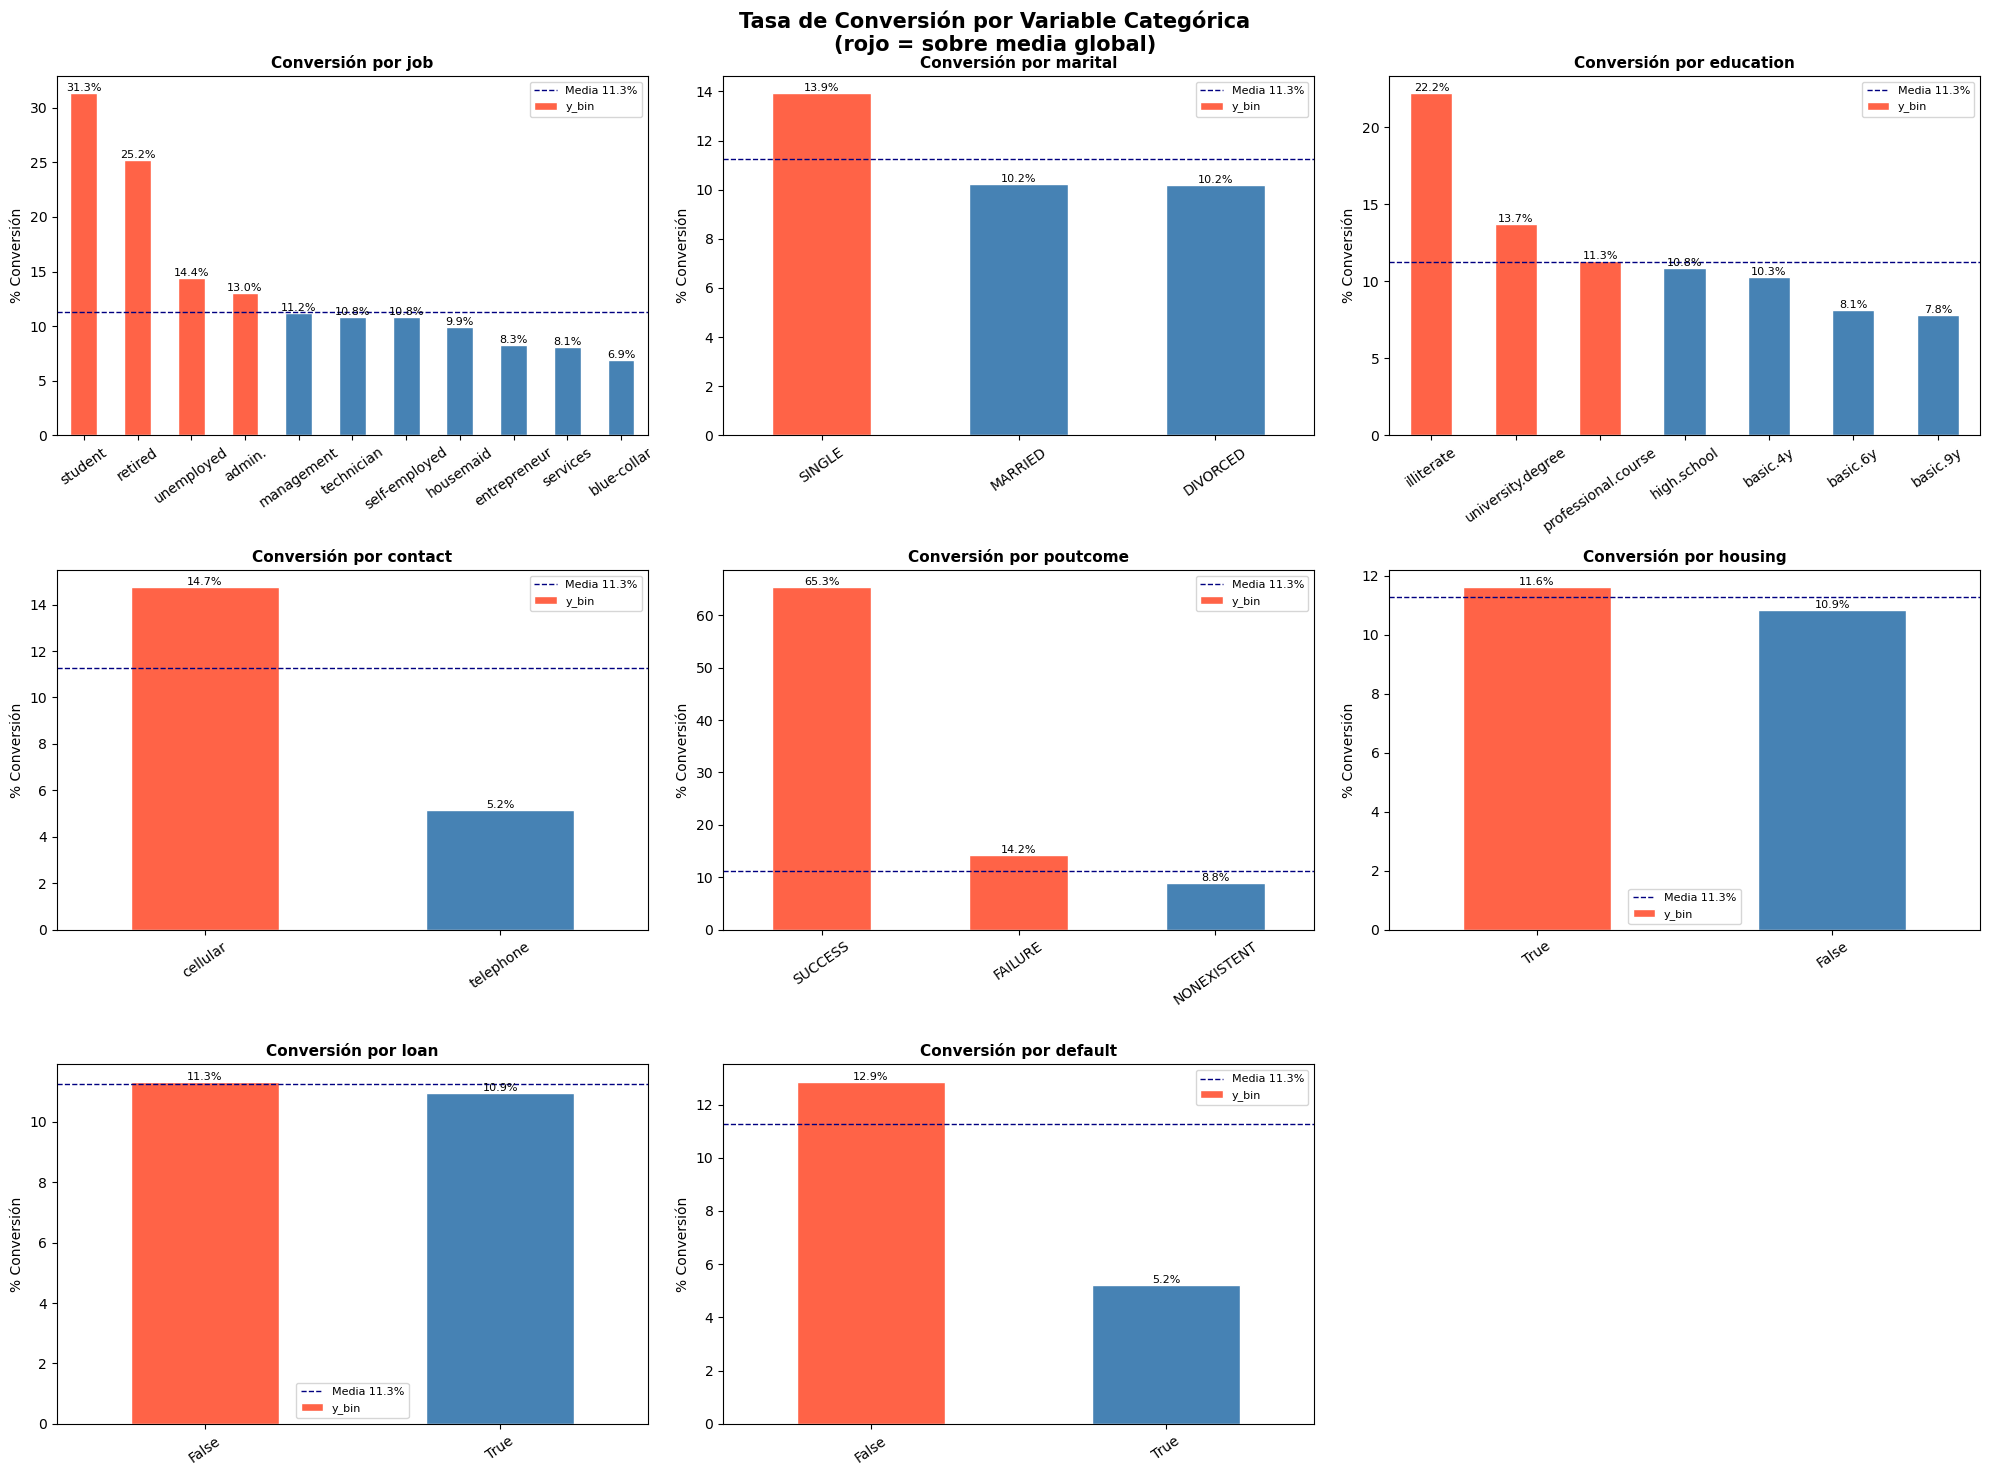

In [115]:
df_merge['y_bin'] = (df_merge['y'] == 'yes').astype(int)
media_global = df_merge['y_bin'].mean() * 100

cat_vars = ['job', 'marital', 'education', 'contact', 'poutcome', 'housing', 'loan', 'default']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    ax = axes[i]
    conv = df_merge.groupby(col, observed=True)['y_bin'].mean().sort_values(ascending=False) * 100
    bars = conv.plot(kind='bar', ax=ax, edgecolor='white',
                     color=['tomato' if v > media_global else 'steelblue' for v in conv])
    ax.axhline(media_global, color='navy', linestyle='--', linewidth=1, label=f'Media {media_global:.1f}%')
    ax.set_title(f'Conversión por {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('% Conversión')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=8)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Tasa de Conversión por Variable Categórica\n(rojo = sobre media global)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [119]:
df_merge.to_csv(r'C:\Users\pablo\iCloudDrive\Master - ThePower\Data Analyst V3\Repositoros_GitHub\Entrega_Phyton_For_Data\Entrega-Proyecto-Python-EDA\DataProyecto/Limpio/merge.csv',
                index=False)

In [121]:
df_limpio = pd.read_csv(r'C:\Users\pablo\iCloudDrive\Master - ThePower\Data Analyst V3\Repositoros_GitHub\Entrega_Phyton_For_Data\Entrega-Proyecto-Python-EDA\DataProyecto\Limpio/merge.csv')
df_limpio

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,dt_customer,numwebvisitsmonth,year,month,year_month,y_bin,pdays_contactado,antiguedad_dias,total_hijos,income_segment
0,NaN,housemaid,MARRIED,basic.4y,False,False,False,telephone,261,1,...,2012-04-04,29,2019.0,8.0,2019-08,0,False,2676.0,1,>120k
1,57.0,services,MARRIED,high.school,True,False,False,telephone,149,1,...,2012-12-30,7,2016.0,9.0,2016-09,0,False,1354.0,2,80k-120k
2,37.0,services,MARRIED,high.school,False,True,False,telephone,226,1,...,2012-02-02,5,2019.0,2.0,2019-02,0,False,2570.0,2,>120k
3,40.0,admin.,MARRIED,basic.6y,False,False,False,telephone,151,1,...,2012-12-21,29,2015.0,11.0,2015-11,0,False,1073.0,3,>120k
4,56.0,services,MARRIED,high.school,False,False,True,telephone,307,1,...,2012-06-20,20,2017.0,1.0,2017-01,0,False,1684.0,3,40k-80k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,NaN,admin.,MARRIED,university.degree,False,False,False,cellular,618,2,...,2014-03-08,22,2015.0,10.0,2015-10,1,False,584.0,2,40k-80k
42996,34.0,technician,MARRIED,professional.course,False,True,True,cellular,42,7,...,2014-03-11,26,2018.0,3.0,2018-03,0,False,1467.0,2,40k-80k
42997,NaN,blue-collar,SINGLE,basic.6y,False,True,False,cellular,391,2,...,2014-09-18,31,2016.0,9.0,2016-09,0,False,728.0,4,<40k
42998,NaN,admin.,MARRIED,university.degree,True,False,False,cellular,674,3,...,2014-05-17,7,2019.0,9.0,2019-09,0,False,1955.0,3,>120k
